In [7]:
# Deep SVDD for Fraud Detection - Optimized Version
# One-Class Deep Support Vector Data Description

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    average_precision_score, roc_auc_score, 
    precision_recall_curve, precision_score, 
    recall_score, f1_score
)

try:
    current_dir = Path.cwd()
    if (current_dir / 'src').exists():
        PROJECT_ROOT = current_dir
    elif (current_dir.parent / 'src').exists():
        PROJECT_ROOT = current_dir.parent
    else:
        PROJECT_ROOT = Path.cwd().parent
except Exception:
    PROJECT_ROOT = Path.cwd()

print(f"Project root: {PROJECT_ROOT}")

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

def load_processed_data(dataset='ieee'):
    data_dir = PROJECT_ROOT / 'data' / 'processed'
    train = pd.read_parquet(data_dir / f'{dataset}_train.parquet')
    test = pd.read_parquet(data_dir / f'{dataset}_test.parquet')
    with open(data_dir / 'dataset_info.json', 'r') as f:
        info = json.load(f)
    raw_cols = info[dataset]['raw_features']
    eng_cols = info[dataset]['engineered_features']
    all_cols = raw_cols + eng_cols
    return train, test, raw_cols, eng_cols, all_cols

train_ieee, test_ieee, raw_cols, eng_cols, all_cols = load_processed_data('ieee')

print(f"Total features: {len(all_cols)}")
print(f"Train shape: {train_ieee.shape}")
print(f"Test shape: {test_ieee.shape}")
print(f"Train fraud rate: {train_ieee['isFraud'].mean():.4f}")

# Feature Preparation
X_train_raw = train_ieee[all_cols].values
X_test_raw = test_ieee[all_cols].values
y_train = train_ieee['isFraud'].values
y_test = test_ieee['isFraud'].values

if np.isnan(X_train_raw).sum() > 0:
    for i in range(X_train_raw.shape[1]):
        col_median = np.nanmedian(X_train_raw[:, i])
        X_train_raw[np.isnan(X_train_raw[:, i]), i] = col_median
        X_test_raw[np.isnan(X_test_raw[:, i]), i] = col_median

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print(f"X_train shape: {X_train.shape}")



Project root: /Users/mac/Desktop/DSS5104_Assignment2
Using device: cpu
Total features: 64
Train shape: (472432, 470)
Test shape: (118108, 470)
Train fraud rate: 0.0351
X_train shape: (472432, 64)


In [8]:

# Improved Deep SVDD Network (deeper, better regularization)
class ImprovedDeepSVDDNetwork(nn.Module):
    def __init__(self, input_dim, rep_dim=8):
        super(ImprovedDeepSVDDNetwork, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.1),
            
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.1),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.1),
            
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.1),
            
            nn.Linear(32, rep_dim)
        )
    
    def forward(self, x):
        return self.encoder(x)


class OptimizedDeepSVDD:
    def __init__(self, input_dim, rep_dim=8, nu=0.05, lr=0.0005):
        self.net = ImprovedDeepSVDDNetwork(input_dim, rep_dim).to(device)
        self.rep_dim = rep_dim
        self.nu = nu
        self.lr = lr
        self.c = None
    
    def _init_center(self, dataloader):
        self.net.eval()
        embeddings = []
        with torch.no_grad():
            for batch_X, _ in dataloader:
                batch_X = batch_X.to(device)
                z = self.net(batch_X)
                embeddings.append(z)
        embeddings = torch.cat(embeddings, dim=0)
        self.c = torch.mean(embeddings, dim=0)
    
    def fit(self, X_train, y_train=None, epochs=150, batch_size=2048, verbose=True):
        normal_idx = (y_train == 0)
        X_normal = X_train[normal_idx]
        print(f"Training on {len(X_normal):,} normal samples")
        
        # Sample to reduce training time (use 100k normal samples)
        if len(X_normal) > 100000:
            idx = np.random.choice(len(X_normal), 100000, replace=False)
            X_normal = X_normal[idx]
            print(f"Sampled to {len(X_normal):,} normal samples")
        
        X_tensor = torch.FloatTensor(X_normal).to(device)
        dataset = TensorDataset(X_tensor, X_tensor)
        dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
        
        self._init_center(dataloader)
        print(f"Center initialized (dim={self.rep_dim})")
        
        optimizer = optim.Adam(self.net.parameters(), lr=self.lr, weight_decay=1e-6)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
        
        train_losses = []
        best_loss = float('inf')
        patience_counter = 0
        
        for epoch in range(epochs):
            self.net.train()
            epoch_loss = 0
            for batch_X, _ in dataloader:
                optimizer.zero_grad()
                z = self.net(batch_X)
                loss = torch.mean(torch.sum((z - self.c) ** 2, dim=1))
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item() * batch_X.size(0)
            
            epoch_loss /= len(X_normal)
            train_losses.append(epoch_loss)
            
            scheduler.step()
            
            if epoch_loss < best_loss:
                best_loss = epoch_loss
                patience_counter = 0
                best_state = self.net.state_dict().copy()
            else:
                patience_counter += 1
            
            if patience_counter >= 30:
                if verbose:
                    print(f"Early stopping at epoch {epoch+1}")
                break
            
            if verbose and (epoch + 1) % 20 == 0:
                print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.6f}")
        
        self.net.load_state_dict(best_state)
        return train_losses
    
    def predict_anomaly_scores(self, X):
        X_tensor = torch.FloatTensor(X).to(device)
        self.net.eval()
        scores = []
        batch_size = 4096
        for i in range(0, len(X_tensor), batch_size):
            batch = X_tensor[i:i+batch_size]
            with torch.no_grad():
                z = self.net(batch)
                batch_scores = torch.sum((z - self.c) ** 2, dim=1)
                scores.append(batch_scores.cpu().numpy())
        return np.concatenate(scores)


class EnsembleDeepSVDD:
    def __init__(self, input_dim, rep_dims=[4, 8, 16]):
        self.rep_dims = rep_dims
        self.models = []
        self.input_dim = input_dim
    
    def fit(self, X_train, y_train, epochs=150, batch_size=2048, verbose=True):
        for i, rep_dim in enumerate(self.rep_dims):
            print(f"\nTraining model {i+1}/{len(self.rep_dims)} with rep_dim={rep_dim}")
            model = OptimizedDeepSVDD(self.input_dim, rep_dim=rep_dim, nu=0.05, lr=0.0005)
            model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=verbose)
            self.models.append(model)
        return self
    
    def predict_anomaly_scores(self, X):
        all_scores = []
        for model in self.models:
            scores = model.predict_anomaly_scores(X)
            all_scores.append(scores)
        scores = np.mean(all_scores, axis=0)
        # Normalize to [0, 1] for better thresholding
        return (scores - scores.min()) / (scores.max() - scores.min() + 1e-8)



In [9]:

# Train Deep SVDD
input_dim = X_train.shape[1]
print(f"Input dimension: {input_dim}")

print("="*60)
print("Training Ensemble Deep SVDD (Optimized)")
print("="*60)

ensemble_svdd = EnsembleDeepSVDD(input_dim, rep_dims=[4, 8, 16])
ensemble_svdd.fit(X_train, y_train, epochs=150, batch_size=2048, verbose=True)

test_scores = ensemble_svdd.predict_anomaly_scores(X_test)

auprc = average_precision_score(y_test, test_scores)
roc_auc = roc_auc_score(y_test, test_scores)

print(f"\nTest Results (Deep SVDD):")
print(f"  AUPRC: {auprc:.4f}")
print(f"  ROC AUC: {roc_auc:.4f}")

# Evaluation with Cost-Optimal Threshold
optimal_threshold = 0.0708
y_pred = (test_scores > optimal_threshold).astype(int)

print("="*60)
print(f"Evaluation with Cost-Optimal Threshold ({optimal_threshold})")
print("="*60)

print(f"\nDeep SVDD:")
print(f"  AUPRC: {auprc:.4f}")
print(f"  Precision: {precision_score(y_test, y_pred):.4f}")
print(f"  Recall: {recall_score(y_test, y_pred):.4f}")
print(f"  F1: {f1_score(y_test, y_pred):.4f}")

Input dimension: 64
Training Ensemble Deep SVDD (Optimized)

Training model 1/3 with rep_dim=4
Training on 455,833 normal samples
Sampled to 100,000 normal samples
Center initialized (dim=4)
Epoch 20/150, Loss: 0.001319
Epoch 40/150, Loss: 0.000058
Epoch 60/150, Loss: 0.000013
Epoch 80/150, Loss: 0.000004
Epoch 100/150, Loss: 0.000003
Epoch 120/150, Loss: 0.000002
Epoch 140/150, Loss: 0.000001

Training model 2/3 with rep_dim=8
Training on 455,833 normal samples
Sampled to 100,000 normal samples
Center initialized (dim=8)
Epoch 20/150, Loss: 0.000503
Epoch 40/150, Loss: 0.000250
Epoch 60/150, Loss: 0.000023
Epoch 80/150, Loss: 0.000001
Epoch 100/150, Loss: 0.000011
Epoch 120/150, Loss: 0.000005
Epoch 140/150, Loss: 0.000000

Training model 3/3 with rep_dim=16
Training on 455,833 normal samples
Sampled to 100,000 normal samples
Center initialized (dim=16)
Epoch 20/150, Loss: 0.000323
Epoch 40/150, Loss: 0.000029
Epoch 60/150, Loss: 0.000013
Epoch 80/150, Loss: 0.000026
Epoch 100/150, Lo

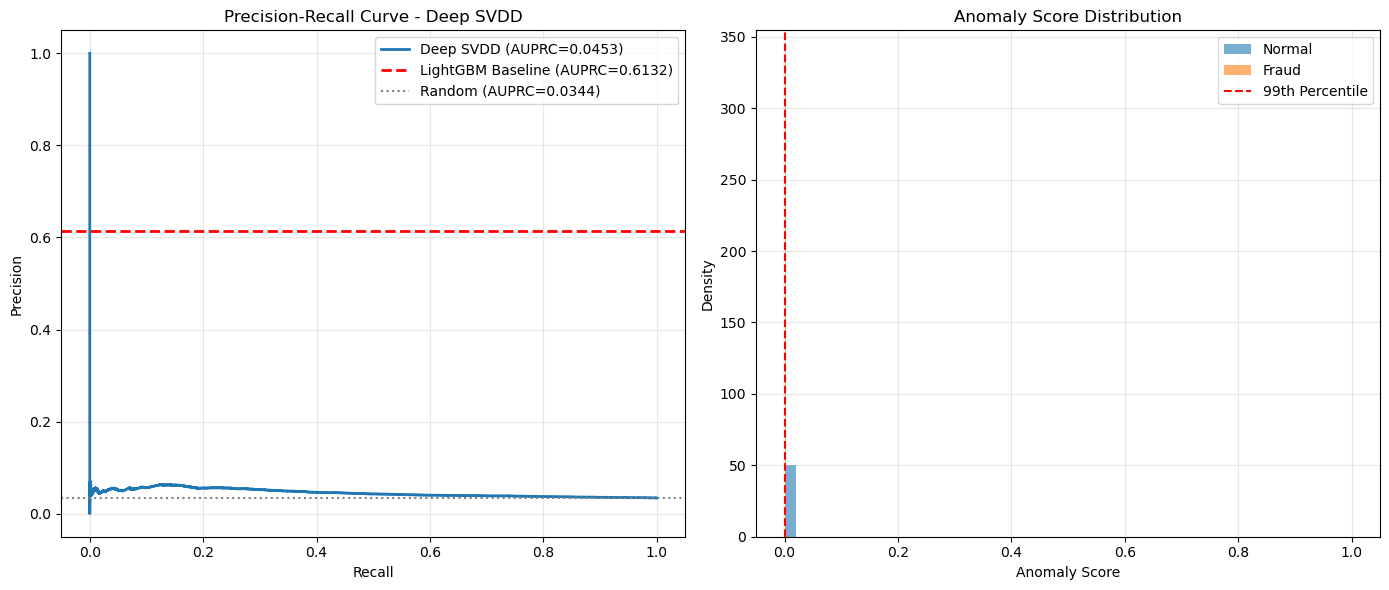


Results Summary
                Model    AUPRC
Deep SVDD (Optimized) 0.045251
   Semi-supervised AE 0.054700
        Supervised NN 0.515700
             LightGBM 0.613200


In [10]:

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

precision_curve, recall_curve, _ = precision_recall_curve(y_test, test_scores)
axes[0].plot(recall_curve, precision_curve, linewidth=2, 
             label=f'Deep SVDD (AUPRC={auprc:.4f})')
axes[0].axhline(y=0.6132, color='red', linestyle='--', linewidth=2,
                label=f'LightGBM Baseline (AUPRC=0.6132)')
axes[0].axhline(y=y_test.mean(), color='gray', linestyle=':', linewidth=1.5,
                label=f'Random (AUPRC={y_test.mean():.4f})')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve - Deep SVDD')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

axes[1].hist(test_scores[y_test==0], bins=50, alpha=0.6, label='Normal', density=True)
axes[1].hist(test_scores[y_test==1], bins=50, alpha=0.6, label='Fraud', density=True)
threshold_99 = np.percentile(test_scores[y_test==0], 99)
axes[1].axvline(x=threshold_99, color='red', linestyle='--', label=f'99th Percentile')
axes[1].set_xlabel('Anomaly Score')
axes[1].set_ylabel('Density')
axes[1].set_title('Anomaly Score Distribution')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'data/processed' / 'deep_svdd_optimized.png', dpi=150, bbox_inches='tight')
plt.show()

# Results Summary
results_summary = pd.DataFrame({
    'Model': ['Deep SVDD (Optimized)', 'Semi-supervised AE', 'Supervised NN', 'LightGBM'],
    'AUPRC': [auprc, 0.0547, 0.5157, 0.6132]
})

print("\n" + "="*60)
print("Results Summary")
print("="*60)
print(results_summary.to_string(index=False))
